In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.cm as cm   
import matplotlib.colors as mcolors
from src import import_data as i_d

In [2]:
i_d.charger_donnees_depuis_bureau()

Dossier trouvé : /Users/charles.ozeel/Desktop/donnees_formule_un
Fichiers CSV trouvés : [PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/circuits.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/status.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/lap_times.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/sprint_results.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/drivers.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/races.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructors.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructor_standings.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/qualifying.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/driver_standings.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructor_results.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees

In [3]:
loca = pd.read_csv("f1_grands_prix_locations.csv")

In [4]:
races.replace("\\N", np.nan, inplace=True)

In [5]:
date = ["date", "fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]
for _ in date:
    races[_] = pd.to_datetime(races[_])

In [6]:
races

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,1140,2024,20,32,Mexico City Grand Prix,2024-10-27,20:00:00,https://en.wikipedia.org/wiki/2024_Mexico_City...,2024-10-25,18:30:00,2024-10-25,22:00:00,2024-10-26,17:30:00,2024-10-26,21:00:00,NaT,NaN
1121,1141,2024,21,18,São Paulo Grand Prix,2024-11-03,17:00:00,https://en.wikipedia.org/wiki/2024_S%C3%A3o_Pa...,2024-11-01,14:30:00,2024-11-01,18:30:00,NaT,NaN,2024-11-02,18:00:00,2024-11-02,14:00:00
1122,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,06:00:00,https://en.wikipedia.org/wiki/2024_Las_Vegas_G...,2024-11-21,02:30:00,2024-11-21,06:00:00,2024-11-22,02:30:00,2024-11-22,06:00:00,NaT,NaN
1123,1143,2024,23,78,Qatar Grand Prix,2024-12-01,17:00:00,https://en.wikipedia.org/wiki/2024_Qatar_Grand...,2024-11-29,13:30:00,2024-11-29,17:30:00,NaT,NaN,2024-11-30,17:00:00,2024-11-30,13:00:00


In [7]:
time = ["time","fp1_time", "fp2_time", "fp3_time", "quali_time", "sprint_time"]
def time_to_decimal(time_str):
    if pd.isna(time_str):
        return np.nan
    h, m, s = map(int, time_str.split(':'))
    return h + m / 60 + s / 3600

for _ in time:
    races[_]=races[_].apply(time_to_decimal)

In [8]:
races[time]

,time,fp1_time,fp2_time,fp3_time,quali_time,sprint_time
0,6.0,NaN,NaN,NaN,NaN,NaN
1,9.0,NaN,NaN,NaN,NaN,NaN
2,7.0,NaN,NaN,NaN,NaN,NaN
3,12.0,NaN,NaN,NaN,NaN,NaN
4,12.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1120,20.0,18.5,22.0,17.5,21.0,NaN
1121,17.0,14.5,18.5,NaN,18.0,14.0
1122,6.0,2.5,6.0,2.5,6.0,NaN
1123,17.0,13.5,17.5,NaN,17.0,13.0


In [9]:
races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   raceId       1125 non-null   int64         
 1   year         1125 non-null   int64         
 2   round        1125 non-null   int64         
 3   circuitId    1125 non-null   int64         
 4   name         1125 non-null   object        
 5   date         1125 non-null   datetime64[ns]
 6   time         394 non-null    float64       
 7   url          1125 non-null   object        
 8   fp1_date     90 non-null     datetime64[ns]
 9   fp1_time     68 non-null     float64       
 10  fp2_date     90 non-null     datetime64[ns]
 11  fp2_time     68 non-null     float64       
 12  fp3_date     72 non-null     datetime64[ns]
 13  fp3_time     53 non-null     float64       
 14  quali_date   90 non-null     datetime64[ns]
 15  quali_time   68 non-null     float64       
 16  sprint

à quelle heure commence en moyenne les courses par circuit ? 
Est ce que les sprints, les essais (free practice) et les qualif commence de manière identique ? 
On remarque ici 
qu'en moyenne on commence à 14h30 les qualif, 15h les sprints,
mais avec une variance de départ entre 4h13 et 4h25 pour les deux 



Idée !!! utiliser une map, localisation géographique 
de chaque course et faire une map colorée des heures de départ des courses à travers le globe 

In [10]:
loca.rename(columns = {"Grand Prix": "name"}, inplace = True)
races = pd.merge(races, loca,how = 'left')

In [3]:
def horaire_moyen_run_f1(races: pd.DataFrame):
    
    loca = pd.read_csv("f1_grands_prix_locations.csv").copy(deep=True)
    
    races = races.copy(deep=True)
    
    races.replace("\\N", np.nan, inplace=True)
    
    date = ["date", "fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]
    
    for _ in date:
        races[_] = pd.to_datetime(races[_])
        
    time = ["time","fp1_time", "fp2_time", "fp3_time", "quali_time", "sprint_time"]
    def time_to_decimal(time_str):
        if pd.isna(time_str):
            return np.nan
        h, m, s = map(int, time_str.split(':'))
        return h + m / 60 + s / 3600
    for _ in time:
        races[_]=races[_].apply(time_to_decimal)
    
    loca.rename(columns = {"Grand Prix": "name"}, inplace = True)
    races = pd.merge(races, loca,how = 'left')
    Long = races.Longitude.unique()
    
    avg = []
    for l in Long:
        a = races[races["Longitude"] == l]
        avg_time_A = [a[_].mean() for _ in time]
        avg.append(avg_time_A)
    for j in range(len(avg[0])):
        data = [avg[i][j] for i in range(len(avg))]
        norm = mcolors.Normalize(vmin=min(data), vmax=max(data))  # Normalisation des valeurs
        cmap = plt.cm.plasma
        shapefile_path = "naturalearth_lowres"
        gdf = gpd.read_file(shapefile_path)
        fig, ax = plt.subplots(figsize=(10, 8))
        gdf.plot(ax=ax)
        scatter = ax.scatter(
            races['Longitude'].unique(),
            races['Latitude'].unique(),
            c=data,
            cmap=cmap,  
            s=50,        
            marker='o',  
            edgecolor='k'  
        )
        fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                     ax=ax,
                     orientation='horizontal',
                     label='Moyenne des temps')
        fig.suptitle(f"Horaire moyen de début de {time[j]}")
        plt.show()

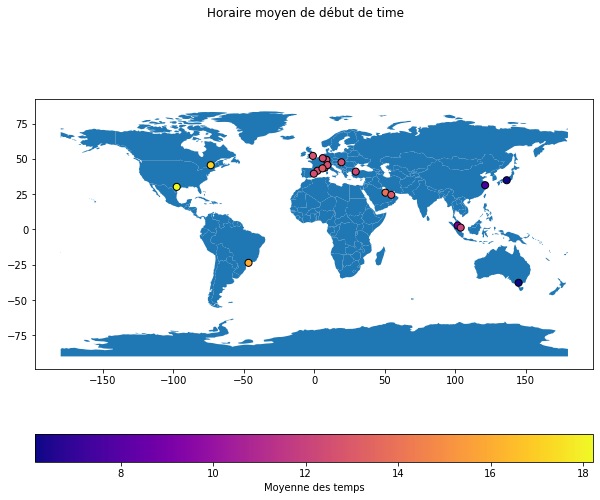

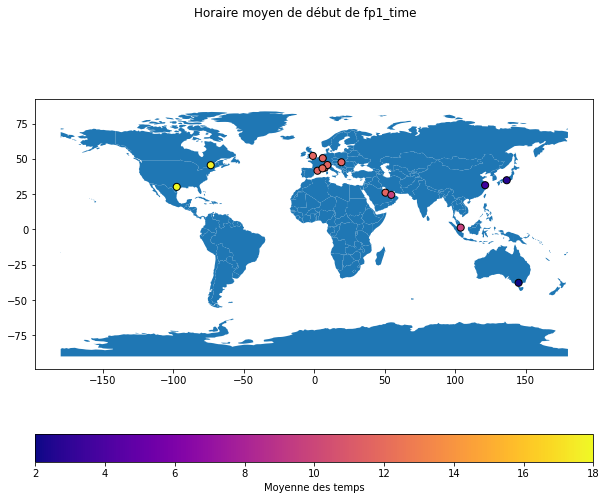

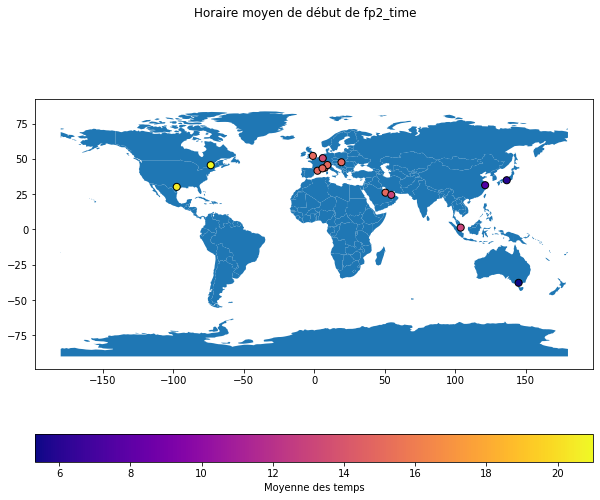

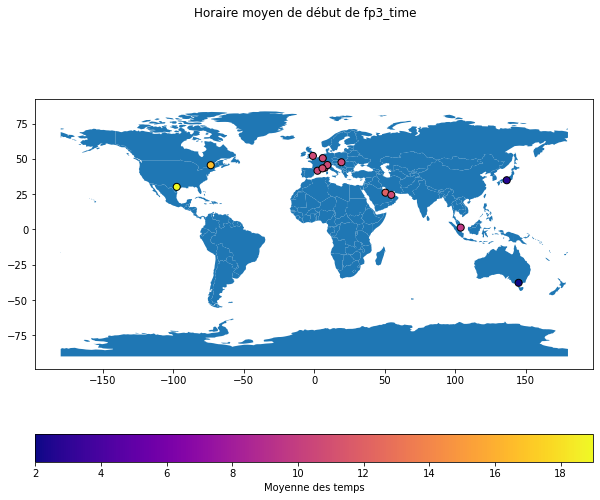

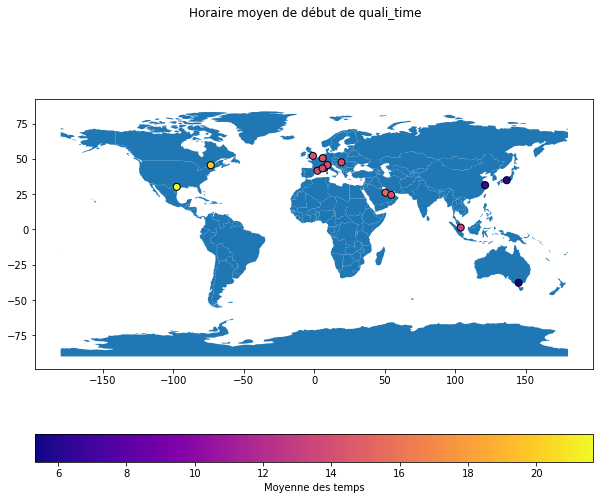

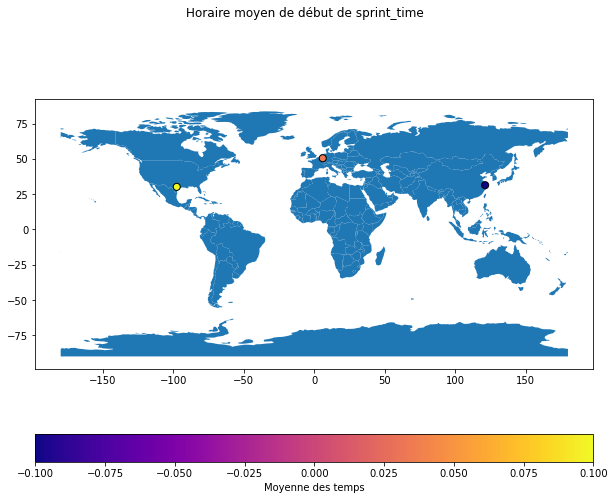

In [6]:
horaire_moyen_run_f1(races)

In [96]:
def min_max_pit_stop_drivers(nom_pilote: str, pit_stops: pd.DataFrame, drivers : pd.DataFrame, param: {"min", "max"}):
    pit_stops = pit_stops.copy(deep = True)
    pit_stops["duration"] = pit_stops["milliseconds"]*(10**(-3))
    pit_stop_min = pit_stops.groupby(["raceId","driverId"]).agg({"duration": "min"}).reset_index()
    pit_stop_max = pit_stops.groupby(["raceId","driverId"]).agg({"duration": "max"}).reset_index()
    a = pd.merge(drivers, pit_stop_min, on="driverId", how="left")
    a.rename(columns={"duration": "min_pit_stop"}, inplace=True)
    a = pd.merge(a, pit_stop_max, on=["driverId", "raceId"], how="left")
    a.rename(columns={"duration": "max_pit_stop"}, inplace=True)
    a["min_pit_stop"] = a["min_pit_stop"].astype(float)
    a["max_pit_stop"] = a["max_pit_stop"].astype(float)
    a = a[ ~a["min_pit_stop"].isna()]
    a = a[ ~a["max_pit_stop"].isna()]
    drivers_mean_min_pit_stop = a.groupby("driverRef").agg({"min_pit_stop": "mean"}).reset_index()
    drivers_mean_max_pit_stop = a.groupby("driverRef").agg({"max_pit_stop": "mean"}).reset_index()
    if param == 'min':
        return drivers_mean_min_pit_stop[drivers_mean_max_pit_stop["driverRef"] == nom_pilote]
    else:
        return drivers_mean_max_pit_stop[drivers_mean_max_pit_stop["driverRef"] == nom_pilote] 
    

In [57]:
pit_stops
#pit_Stops le plus court par pilote/courses#
#arrêt aux stands pour pénalité ou techniques. #

pit_stops["duration"] = pit_stops["milliseconds"]*(10**(-3))

In [58]:
pit_stop_min = pit_stops.groupby(["raceId","driverId"]).agg({"duration": "min"}).reset_index()
pit_stop_max = pit_stops.groupby(["raceId","driverId"]).agg({"duration": "max"}).reset_index()

In [59]:

a = pd.merge(drivers, pit_stop_min, on="driverId", how="left")
a.rename(columns={"duration": "min_pit_stop"}, inplace=True)

a = pd.merge(a, pit_stop_max, on=["driverId", "raceId"], how="left")
a.rename(columns={"duration": "max_pit_stop"}, inplace=True)

In [64]:
a["min_pit_stop"] = a["min_pit_stop"].astype(float)
a["max_pit_stop"] = a["max_pit_stop"].astype(float)

In [70]:
a = a[ ~a["min_pit_stop"].isna()]
a = a[ ~a["max_pit_stop"].isna()]

In [72]:
drivers_mean_min_pit_stop = a.groupby("driverRef").agg({"min_pit_stop": "mean"}).reset_index()
drivers_mean_max_pit_stop = a.groupby("driverRef").agg({"max_pit_stop": "mean"}).reset_index()

In [73]:
drivers_mean_min_pit_stop

,driverRef,min_pit_stop
0,aitken,24.863000
1,albon,51.434908
2,alguersuari,22.535611
3,alonso,43.170922
4,ambrosio,22.871333
...,...,...
69,vergne,23.598509
70,vettel,27.845924
71,webber,22.015696
72,wehrlein,24.996444


In [74]:
drivers_mean_max_pit_stop

,driverRef,max_pit_stop
0,aitken,40.028000
1,albon,154.229184
2,alguersuari,25.130000
3,alonso,156.677463
4,ambrosio,26.688833
...,...,...
69,vergne,46.252509
70,vettel,120.838205
71,webber,26.157232
72,wehrlein,148.526389


In [75]:
drivers_mean_min_pit_stop.min()

driverRef          aitken
min_pit_stop    21.428077
dtype: object

In [77]:
drivers_mean_min_pit_stop.max()

driverRef           zhou
min_pit_stop    98.68029
dtype: object

In [78]:
drivers_mean_max_pit_stop.min()

driverRef       aitken
max_pit_stop    22.457
dtype: object

In [79]:
drivers_mean_max_pit_stop.max()

driverRef          zhou
max_pit_stop    501.194
dtype: object

In [85]:
drivers_mean_min_pit_stop[drivers_mean_min_pit_stop["driverRef"] == "hamilton"]

,driverRef,min_pit_stop
22,hamilton,31.986808


In [97]:
min_max_pit_stop_drivers("hamilton", pit_stops, drivers, "min")

,driverRef,min_pit_stop
22,hamilton,31.986808


In [89]:
drivers_mean_min_pit_stop[drivers_mean_max_pit_stop["driverRef"] == "verstappen"]

,driverRef,min_pit_stop


In [93]:
pit_stops[pit_stops["driverId"] == 50]

,raceId,driverId,stop,lap,time,duration,milliseconds


In [94]:
drivers [drivers["driverId"] == 50]

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
49,50,verstappen,\N,\N,Jos,Verstappen,1972-03-04,Dutch,http://en.wikipedia.org/wiki/Jos_Verstappen
